In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import bayesflow as bf
pd.set_option("display.max_columns", 100)

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
from benchmark.examples.diffusion.config import MODELS, RESULT_DIR, TrainingConfig, ensure_dirs
from benchmark.examples.diffusion.dataset import wagenmakers
from benchmark.examples.diffusion.simulators import SIMULATORS
from benchmark.examples.diffusion.approximators.indirect import load_approximator, load_history
from benchmark.examples.diffusion.results.results import (
    attach_gold_standard,
    estimate_model_comparison,
    load_results,
    save_results,
)
from benchmark.examples.diffusion.results.summary_diagnostic import (
    add_summary_diagnostics,
    fit_references,
    load_diagnostic,
    load_references,
    save_diagnostic,
    save_references,
)
from benchmark.examples.diffusion.results.plots import (
    plot_logml_error_vs_rho,
    plot_pmp_error_vs_log_ambiguity,
    plot_pmp_error_vs_rho,
    plot_pmp_estimates_vs_distance,
)

ensure_dirs()


In [3]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [4]:
config = TrainingConfig(epochs=50, batch_size=64, num_batches=64, summary_multiplier=6)
summary_tag = config.summary_label
results_path = RESULT_DIR / f"npe_{summary_tag}_results_gold.csv"
references_path = RESULT_DIR / f"npe_{summary_tag}_references.pkl"
diagnostic_path = RESULT_DIR / f"npe_{summary_tag}_empirical_diagnostic.csv"

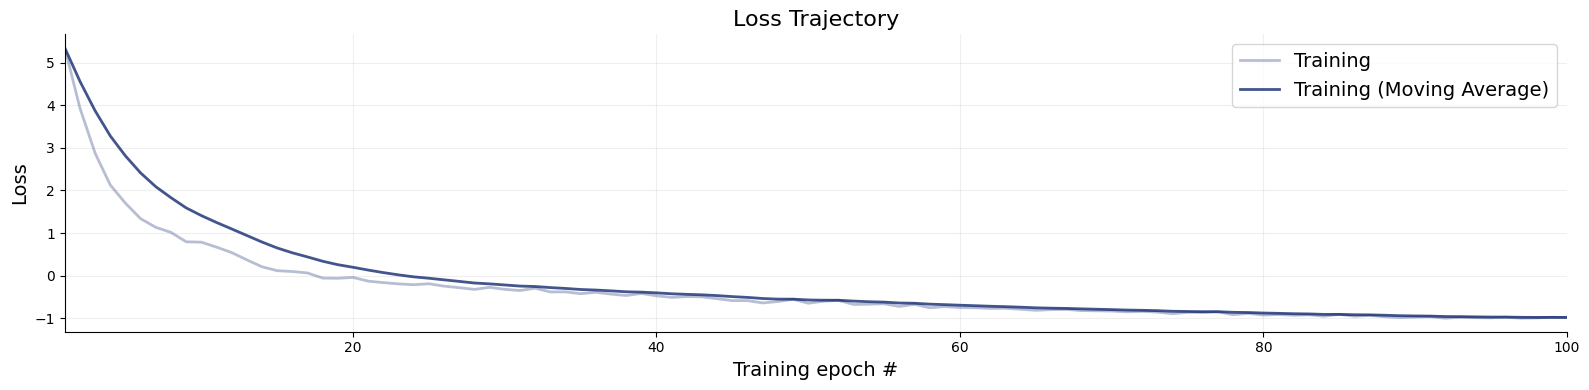

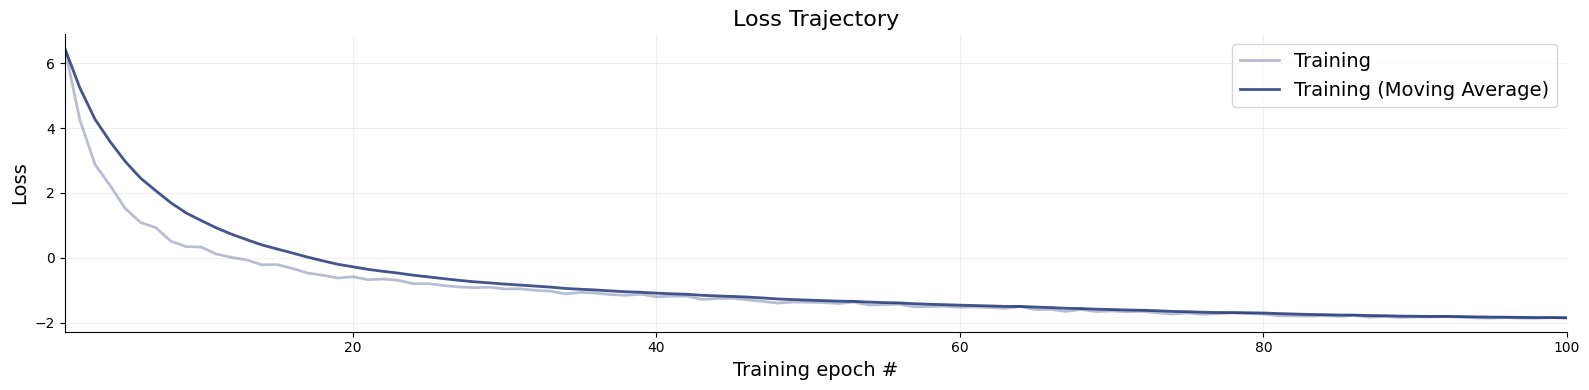

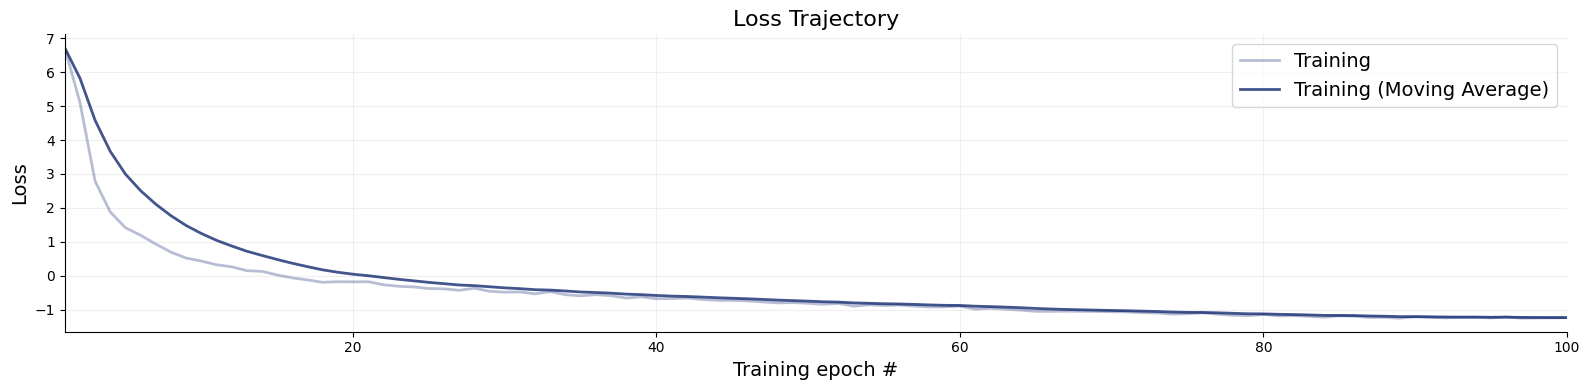

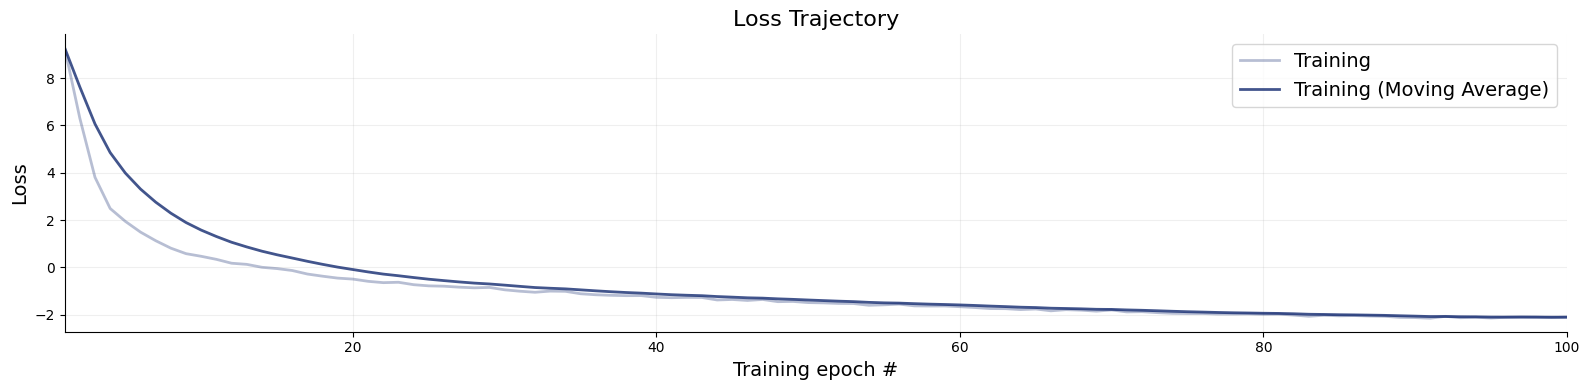

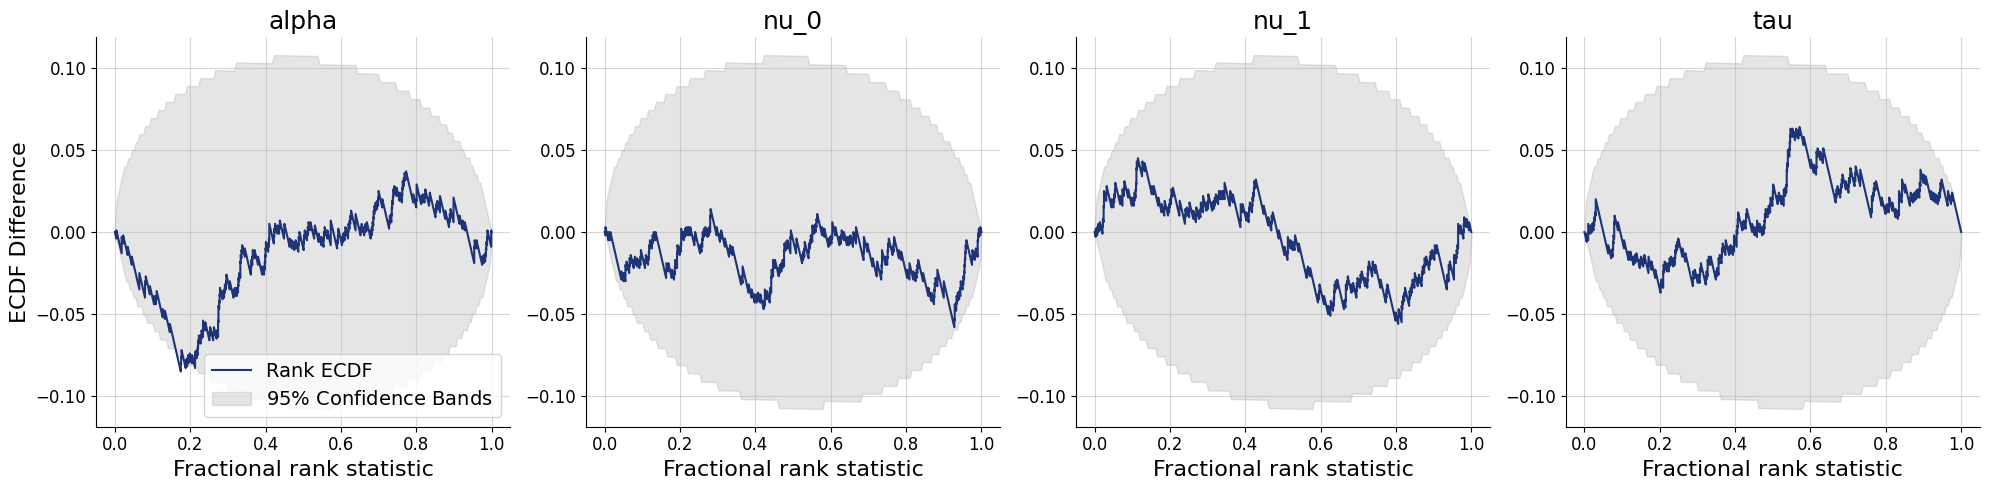

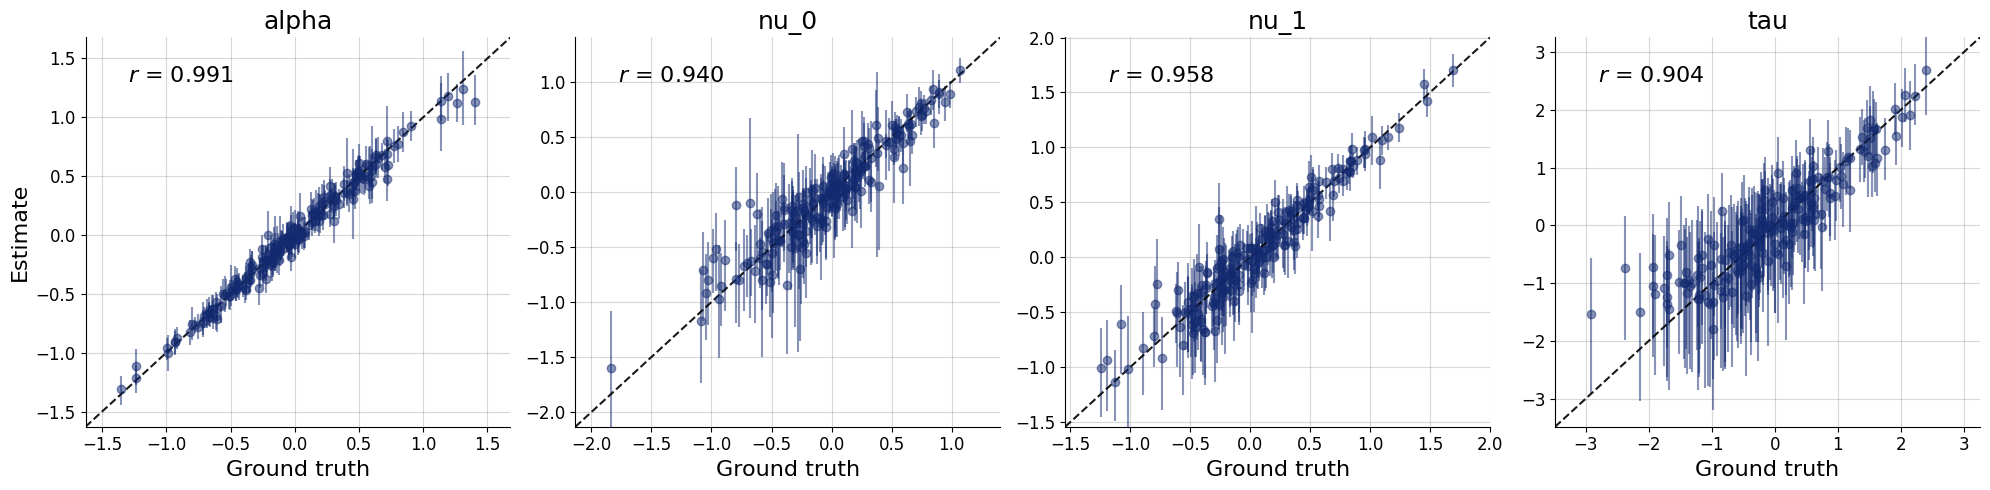

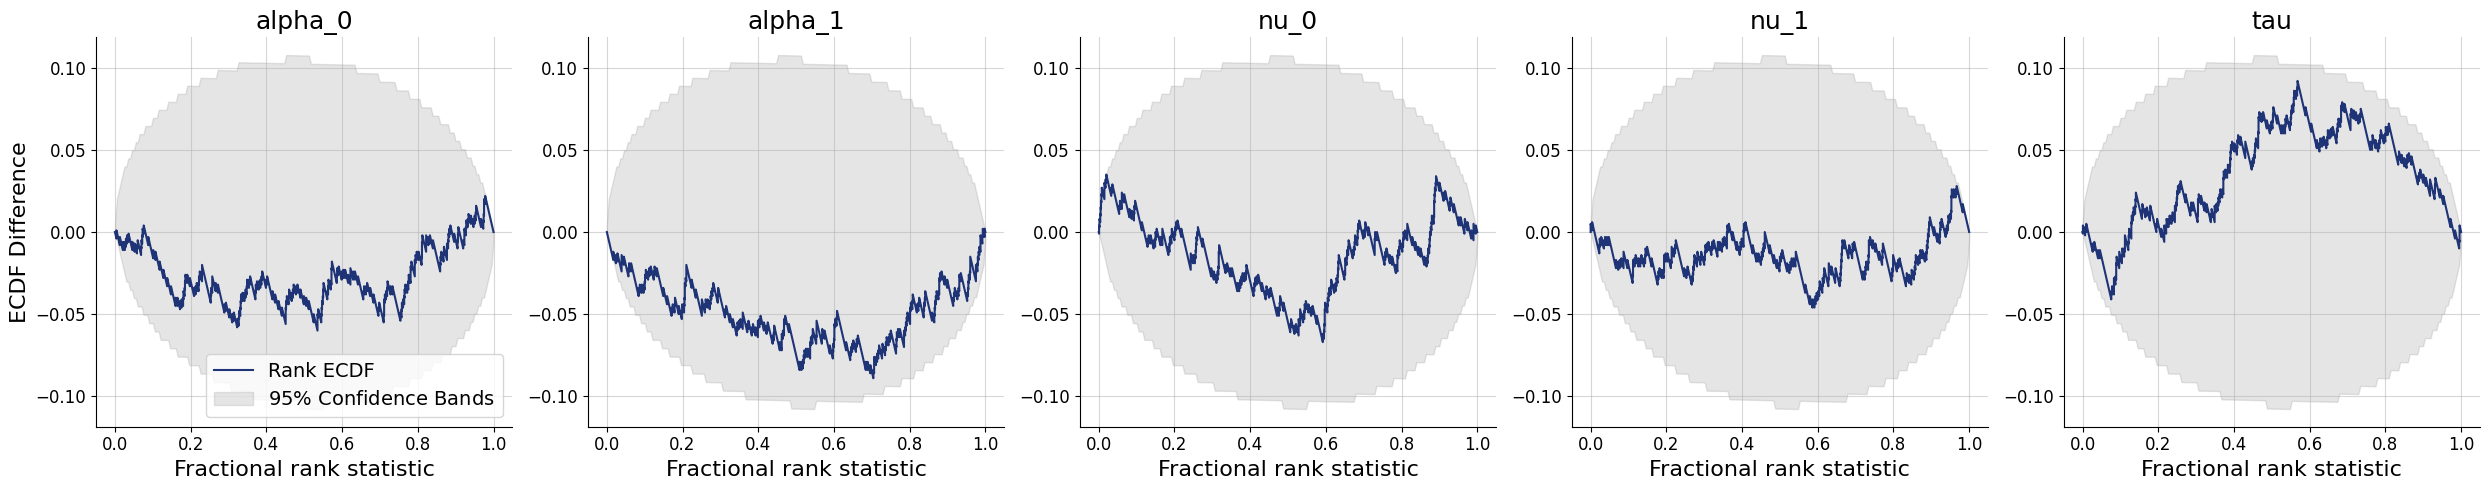

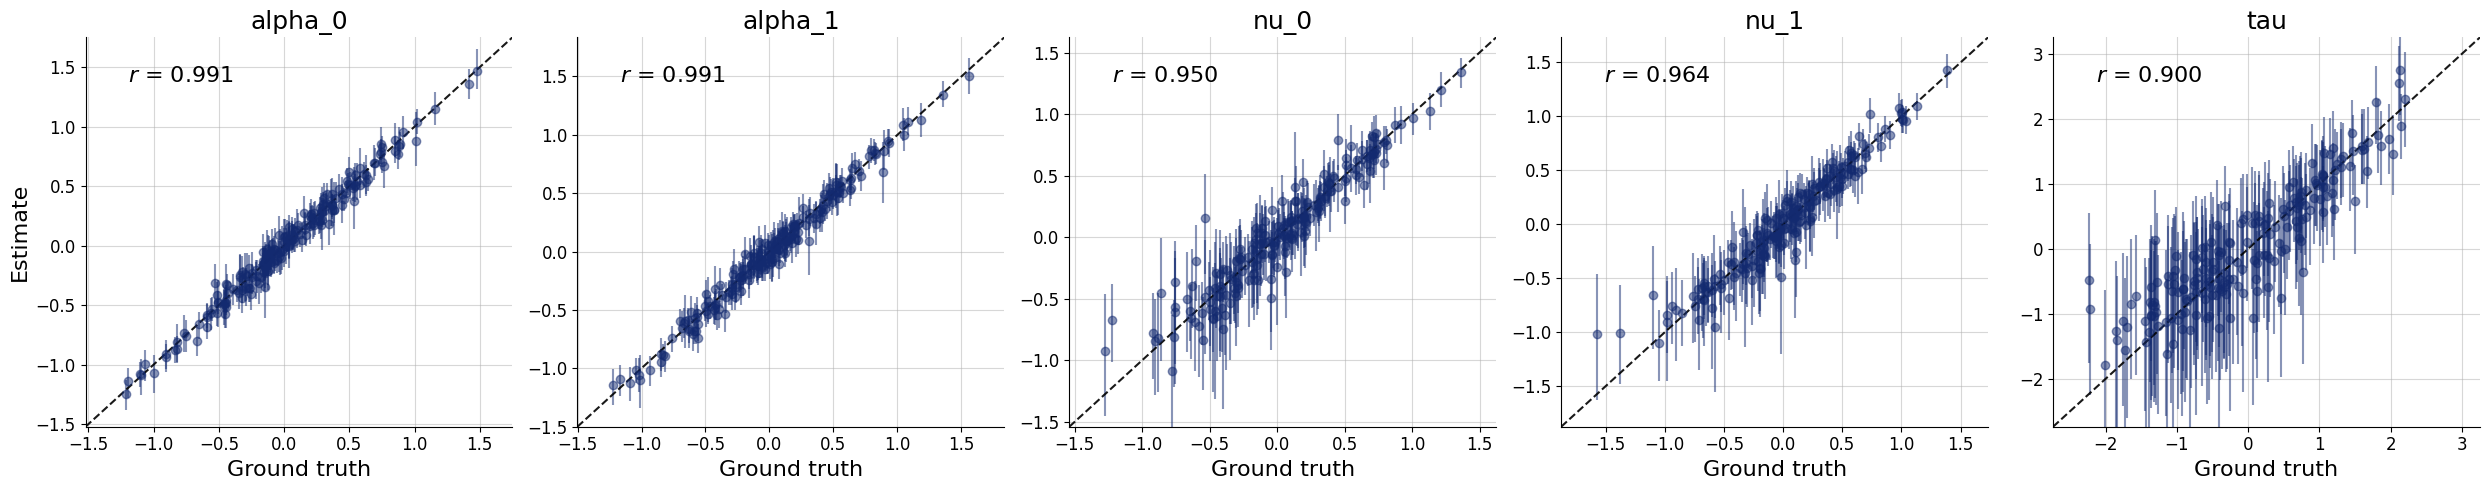

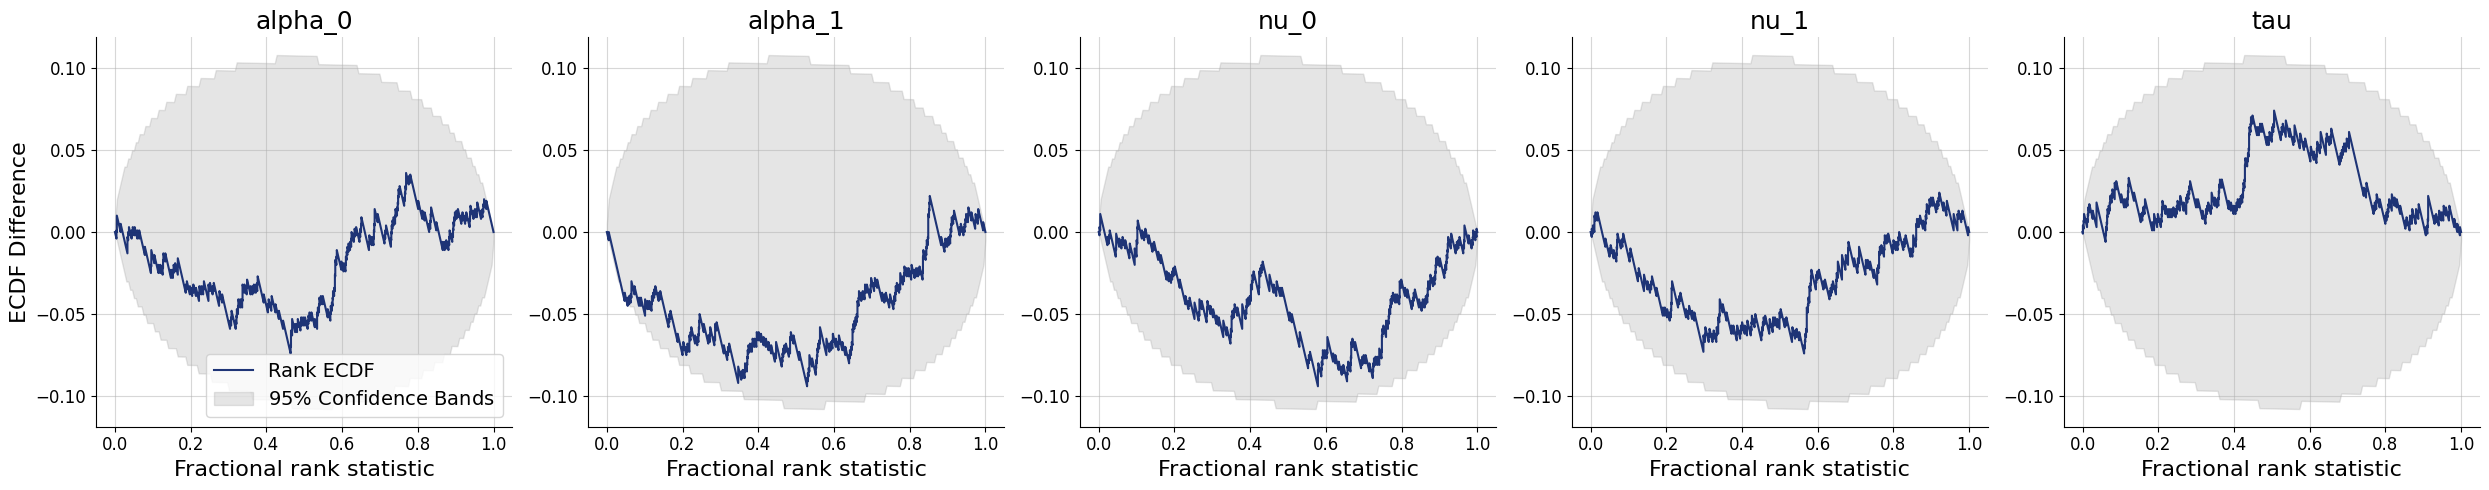

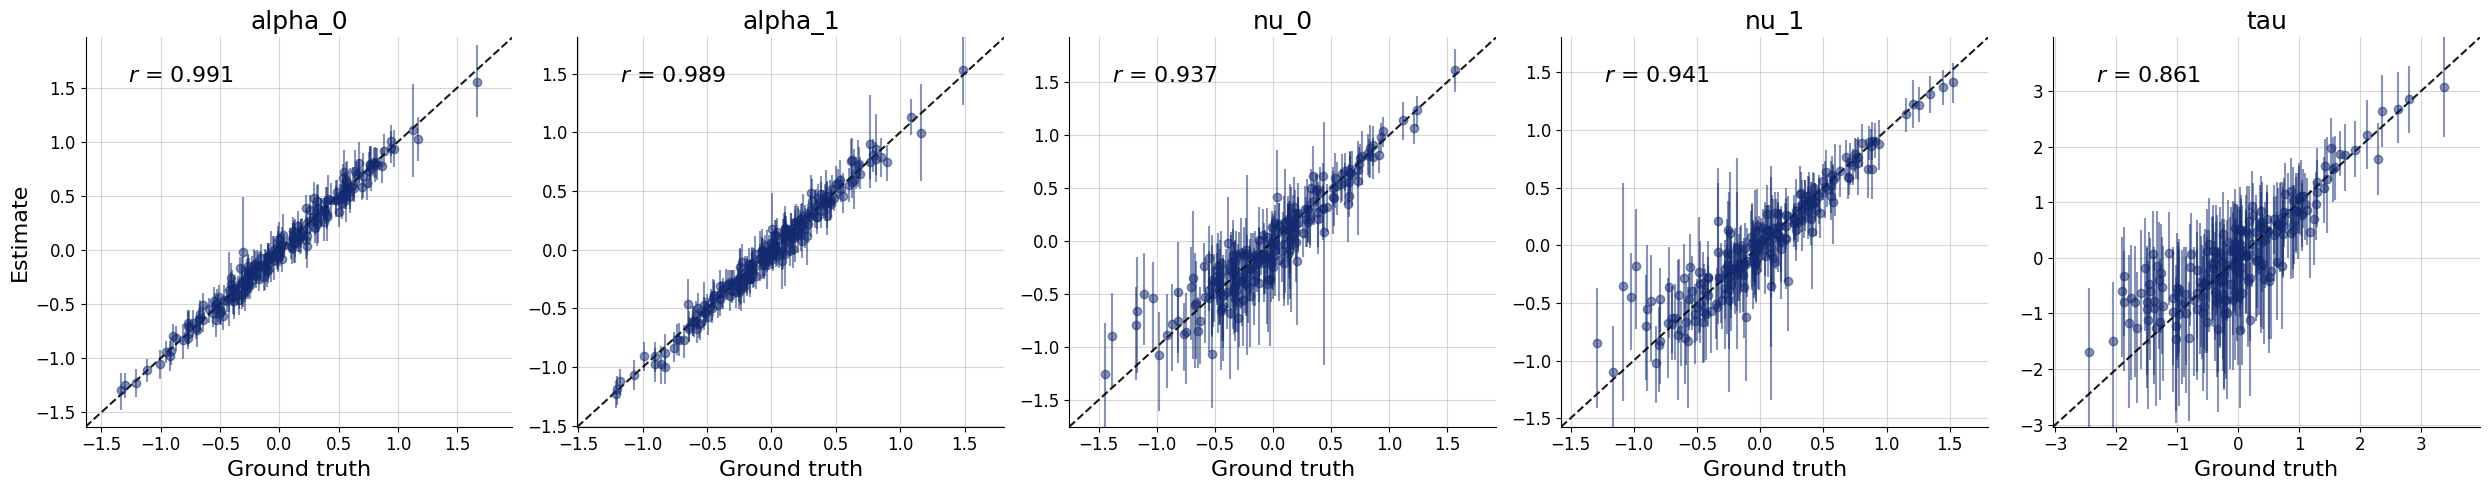

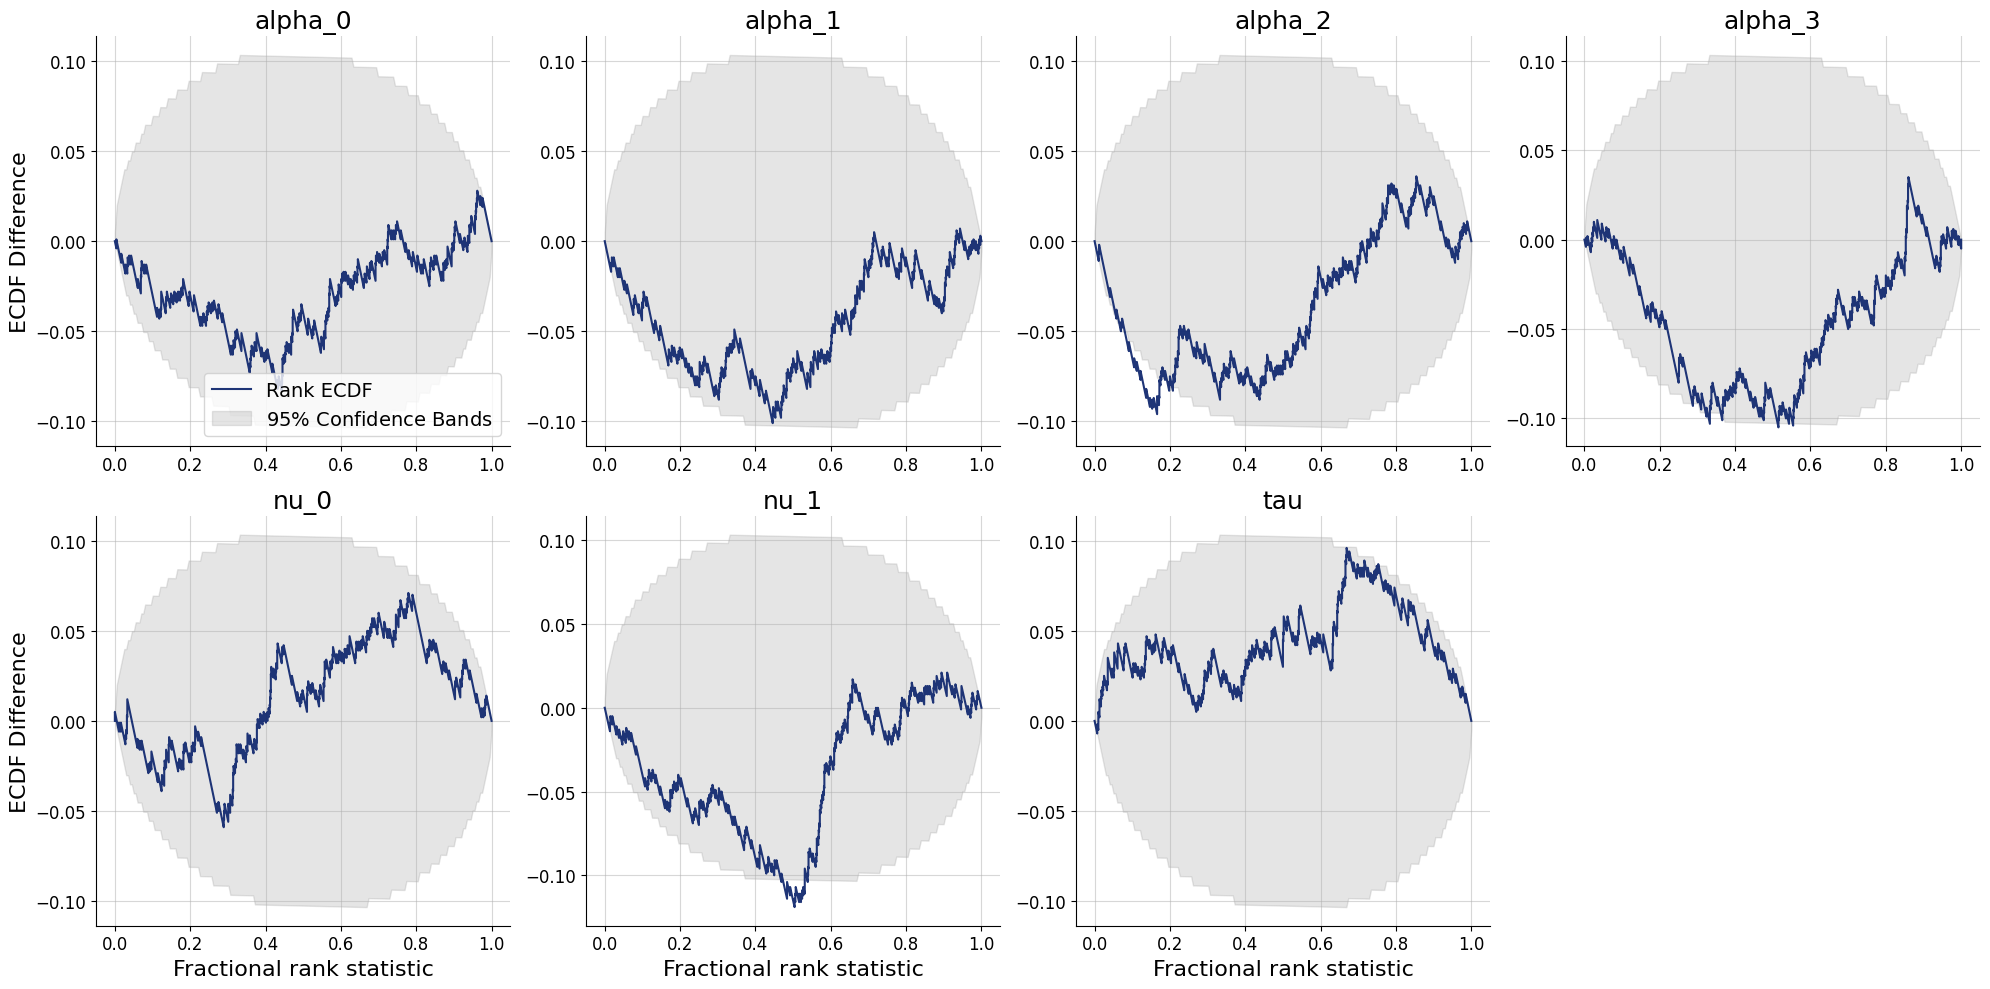

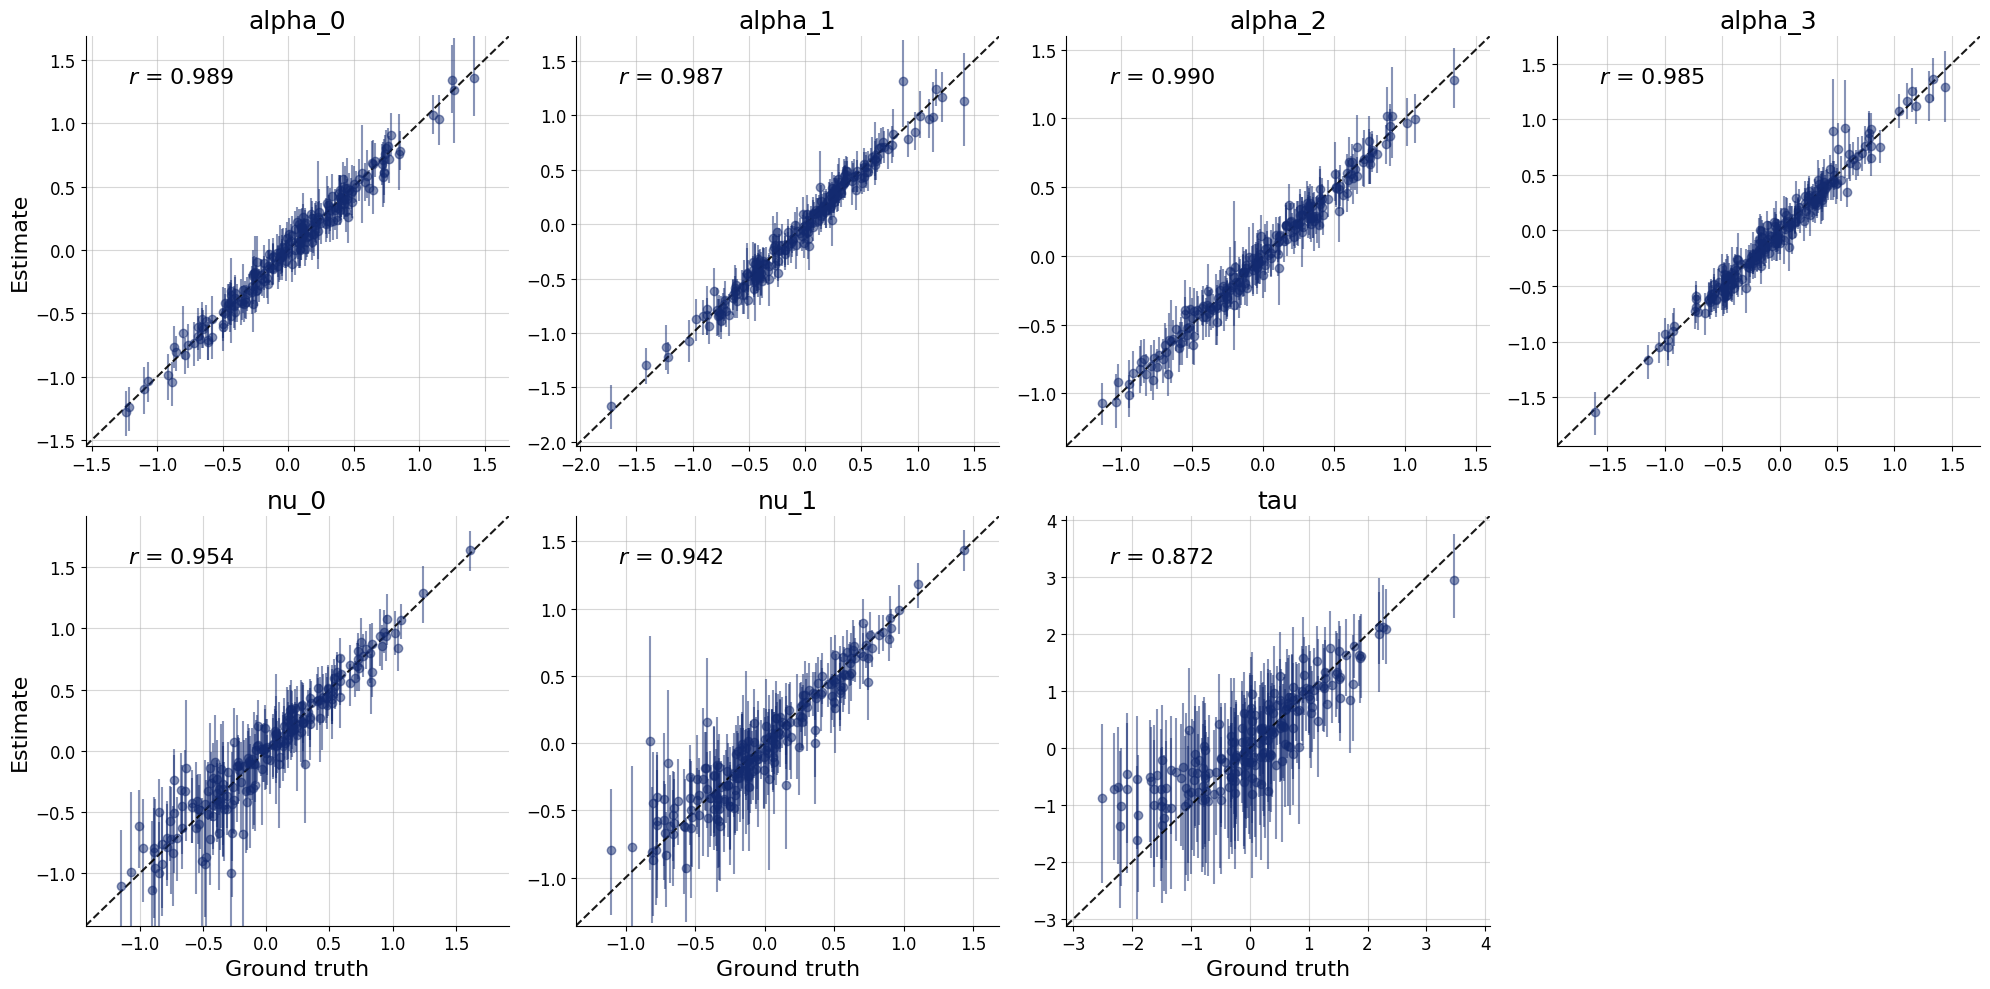

In [5]:
approximators = {model: load_approximator(model, config=config) for model in MODELS}
histories = {model: load_history(model, config=config) for model in MODELS}

for model in MODELS:
    bf.diagnostics.plots.loss(histories[model])

num_samples = 1000
for model in MODELS:
    val_sims = SIMULATORS[model].sample(200)
    post_draws = approximators[model].sample(conditions=val_sims, num_samples=num_samples)
    bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims, difference=True)
    bf.diagnostics.plots.recovery(post_draws, val_sims)
